In [8]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/second_neural_network_a/version_2/metrics.csv"
metrics_df = pd.read_csv(file_path)


print(metrics_df.isnull().sum())  # Count missing values in each column




train_f1_score_step      800
step                       0
train_loss_step          800
epoch                      0
val_loss                1360
val_f1_score            1360
train_f1_score_epoch    1360
train_loss_epoch        1360
dtype: int64


In [10]:
# Check if required columns exist
required_columns = {'epoch', 'train_loss_epoch', 'val_loss'}
if required_columns.issubset(metrics_df.columns):
    # Filter the DataFrame for the required columns
    filtered_df = metrics_df[['epoch', 'train_loss_epoch', 'val_loss']].dropna()
    
    # Get the distinct (unique) rows
    distinct_epochs_and_loss = filtered_df.drop_duplicates()
    
    # Display the distinct rows
    print("Distinct values of 'epoch', 'train_loss_epoch', and 'val_loss':\n", distinct_epochs_and_loss)
else:
    print("One or more required columns are missing from the DataFrame.")

Distinct values of 'epoch', 'train_loss_epoch', and 'val_loss':
 Empty DataFrame
Columns: [epoch, train_loss_epoch, val_loss]
Index: []


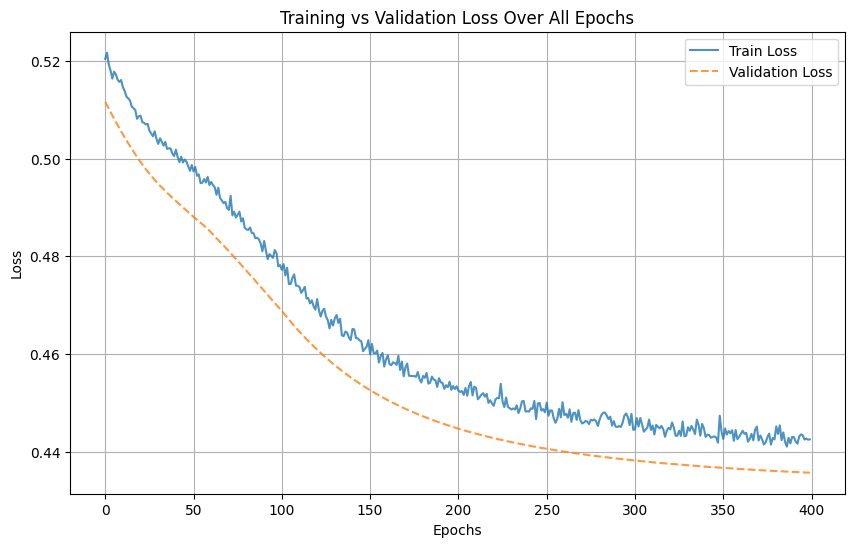

In [12]:
import pandas as pd
import matplotlib.pyplot as plt



# Check if required columns exist
if 'epoch' in metrics_df.columns and 'train_loss_epoch' in metrics_df.columns and 'val_loss' in metrics_df.columns:
    # Group by epoch to compute the mean loss values (in case of duplicate entries)
    grouped_metrics = metrics_df.groupby('epoch').mean()

    # Plot training and validation loss for all epochs
    plt.figure(figsize=(10, 6))
    plt.plot(grouped_metrics.index, grouped_metrics['train_loss_epoch'], label='Train Loss', linestyle='-', alpha=0.8)
    plt.plot(grouped_metrics.index, grouped_metrics['val_loss'], label='Validation Loss', linestyle='--',  alpha=0.8)

    # Labels and title
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss Over All Epochs")
    plt.legend()
    plt.grid(True)

    # Show the plot
    plt.show()
else:
    print("Required columns ('epoch', 'train_loss_epoch', 'val_loss') not found in the metrics file.")


# Overall model F1 score

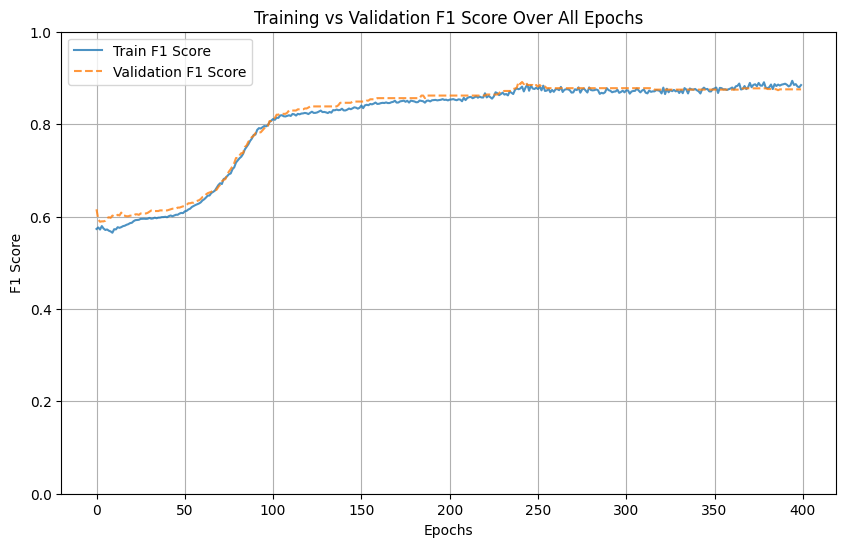

In [17]:
# Check if required columns exist
if 'epoch' in metrics_df.columns and 'train_f1_score_epoch' in metrics_df.columns and 'val_f1_score' in metrics_df.columns:
    # Group by epoch to compute the mean F1 score values (if duplicates exist)
    grouped_metrics = metrics_df.groupby('epoch').mean()

    # Plot training and validation F1 score for all epochs
    plt.figure(figsize=(10, 6))
    plt.plot(grouped_metrics.index, grouped_metrics['train_f1_score_epoch'], label='Train F1 Score', linestyle='-', alpha=0.8)
    plt.plot(grouped_metrics.index, grouped_metrics['val_f1_score'], label='Validation F1 Score', linestyle='--', alpha=0.8)

    # Labels and title
    plt.xlabel("Epochs")
    plt.ylabel("F1 Score")
    plt.title("Training vs Validation F1 Score Over All Epochs")
    plt.ylim(0,1)
    plt.legend()
    plt.grid(True)

    # Show the plot
    plt.show()
else:
    print("Required columns ('epoch', 'train_f1_score_epoch', 'val_f1_score') not found in the metrics file.")


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/second_neural_network_a/version_2/metrics_per_user.csv"
metrics_user_df = pd.read_csv(file_path)

# Extract only the relevant columns
if all(col in metrics_user_df.columns for col in ['mode', 'epoch', 'user', 'f1_score']):
    selected_metrics = metrics_user_df[['mode', 'epoch', 'user', 'f1_score']]
    
    # Display the extracted DataFrame
    print(selected_metrics.head())  # Show first few rows
else:
    print("One or more required columns ('mode', 'epoch', 'user', 'f1_score') are missing in the dataset.")



  mode  epoch  user  f1_score
0  val      0     0  0.625000
1  val      0     1  0.000000
2  val      0     2  0.000000
3  val      0     3  0.545455
4  val      0     4  0.666667


# Train mode - all three days - each users - f1 score and optimal threshold

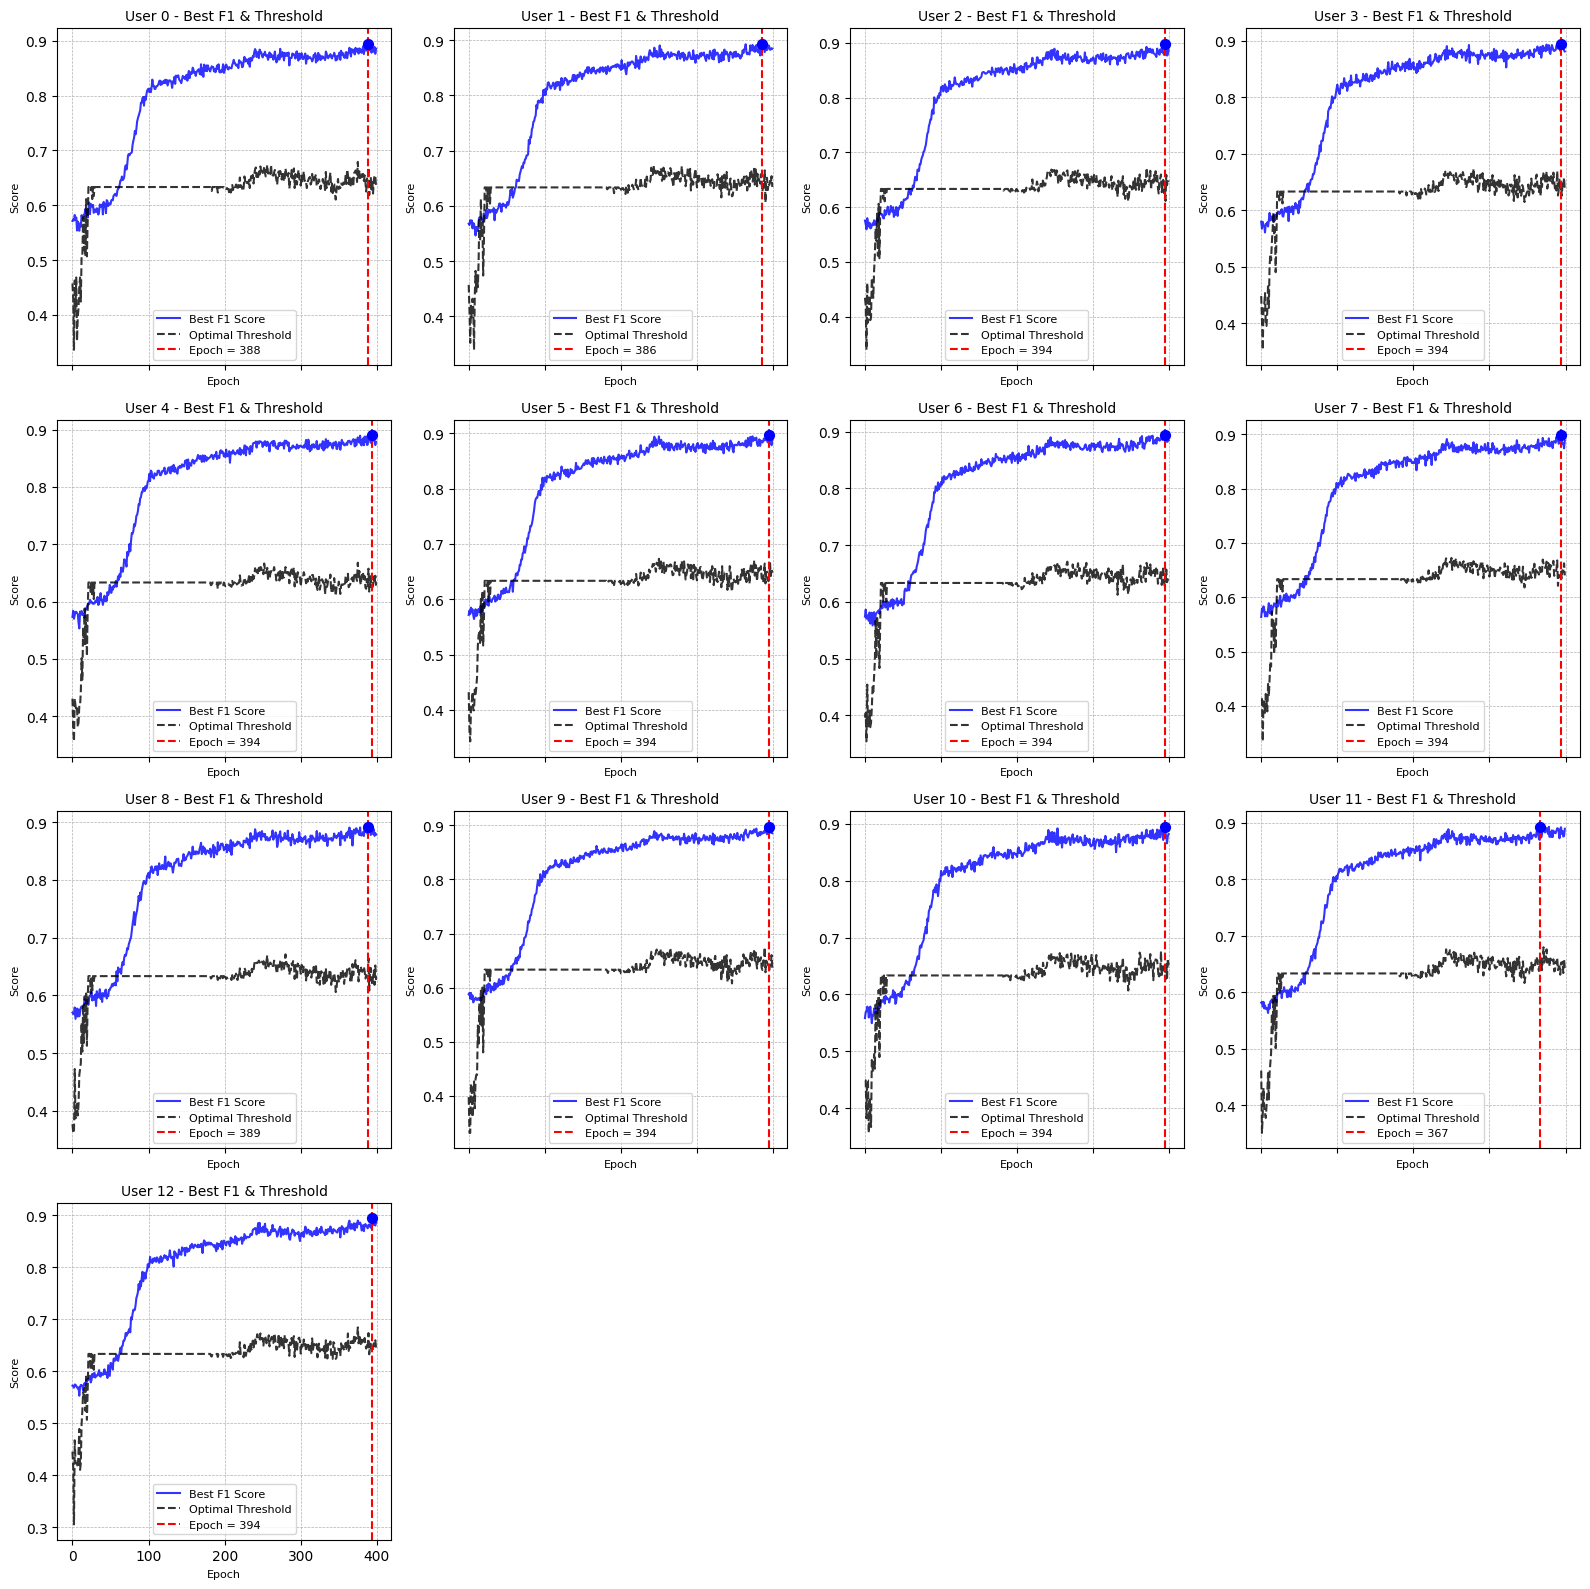

Max F1 Score and Optimal Threshold for Each User:
User 0 -> Epoch: 388, Max F1 Score: 0.8948, Optimal Threshold: 0.6434
User 1 -> Epoch: 386, Max F1 Score: 0.8935, Optimal Threshold: 0.6256
User 2 -> Epoch: 394, Max F1 Score: 0.8987, Optimal Threshold: 0.6363
User 3 -> Epoch: 394, Max F1 Score: 0.8948, Optimal Threshold: 0.6483
User 4 -> Epoch: 394, Max F1 Score: 0.8902, Optimal Threshold: 0.6244
User 5 -> Epoch: 394, Max F1 Score: 0.8965, Optimal Threshold: 0.6326
User 6 -> Epoch: 394, Max F1 Score: 0.8938, Optimal Threshold: 0.6278
User 7 -> Epoch: 394, Max F1 Score: 0.8985, Optimal Threshold: 0.6487
User 8 -> Epoch: 389, Max F1 Score: 0.8923, Optimal Threshold: 0.6644
User 9 -> Epoch: 394, Max F1 Score: 0.8976, Optimal Threshold: 0.6402
User 10 -> Epoch: 394, Max F1 Score: 0.8950, Optimal Threshold: 0.6521
User 11 -> Epoch: 367, Max F1 Score: 0.8929, Optimal Threshold: 0.6473
User 12 -> Epoch: 394, Max F1 Score: 0.8942, Optimal Threshold: 0.6486


In [22]:
# Extract only relevant columns for train mode
train_data = metrics_user_df[metrics_user_df["mode"] == "train"][["epoch", "user", "f1_score", "threshold"]]

# Get unique users
unique_users = sorted(train_data["user"].unique())

# Create subplots (one for each user)
rows = len(unique_users) // 4 + (len(unique_users) % 4 > 0)  # Arrange in rows of 4
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows), sharex=True, sharey=False)
axes = axes.flatten()

# Dictionary to store max F1 score and corresponding threshold for each user
max_f1_info = {}

# Plot each user's F1 score & Threshold
for i, user in enumerate(unique_users):
    user_data = train_data[train_data["user"] == user].groupby("epoch").mean(numeric_only=True)

    axes[i].plot(user_data.index, user_data["f1_score"], linestyle="-", color="blue", label="Best F1 Score", alpha=0.8)
    axes[i].plot(user_data.index, user_data["threshold"], linestyle="--", color="black", label="Optimal Threshold", alpha=0.8)

    # Highlight max F1 Score Epoch
    max_f1_epoch = user_data["f1_score"].idxmax()
    max_f1_score = user_data.loc[max_f1_epoch, "f1_score"]
    optimal_threshold = user_data.loc[max_f1_epoch, "threshold"]
    
    # Store the results
    max_f1_info[user] = {"Epoch": max_f1_epoch, "Max F1 Score": max_f1_score, "Optimal Threshold": optimal_threshold}

    axes[i].axvline(x=max_f1_epoch, color="red", linestyle="--", label=f"Epoch = {max_f1_epoch}")

    # Scatter plot max F1 Score
    axes[i].scatter(max_f1_epoch, user_data.loc[max_f1_epoch, "f1_score"], color="blue", s=50, zorder=5)

    # Titles & Legends
    axes[i].set_title(f"User {user} - Best F1 & Threshold", fontsize=10)
    axes[i].set_xlabel("Epoch", fontsize=8)
    axes[i].set_ylabel("Score", fontsize=8)
    axes[i].grid(True, linestyle="--", linewidth=0.5)
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

# Print Max F1 Score and Optimal Threshold for each user
print("Max F1 Score and Optimal Threshold for Each User:")
for user, values in max_f1_info.items():
    print(f"User {user} -> Epoch: {values['Epoch']}, Max F1 Score: {values['Max F1 Score']:.4f}, Optimal Threshold: {values['Optimal Threshold']:.4f}")

# Validation mode - all three days - each users - f1 score and optimal threshold

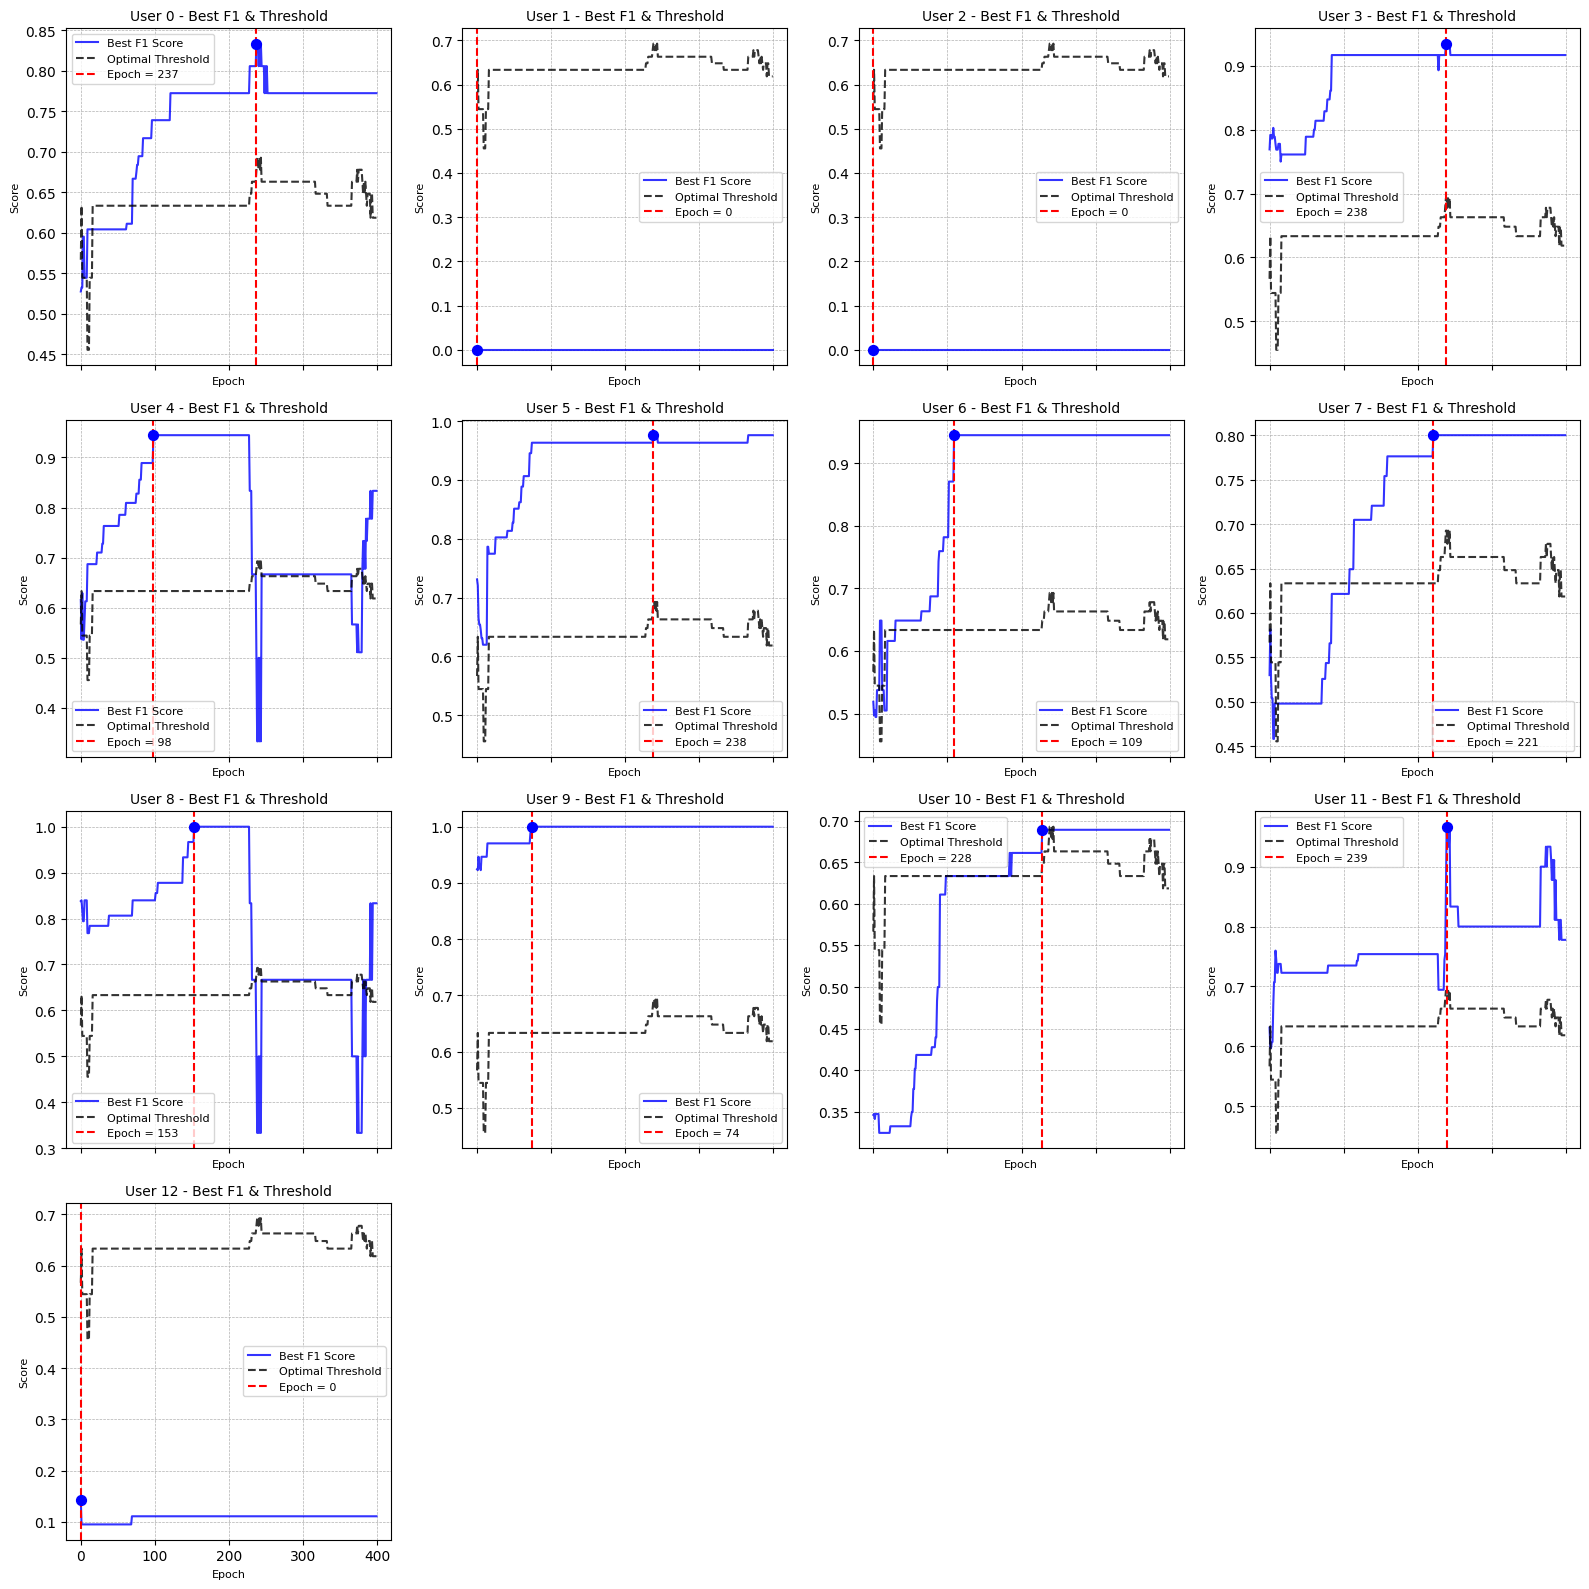

In [ ]:
# Extract only relevant columns for val mode
val_data = metrics_user_df[metrics_user_df["mode"] == "val"][["epoch", "user", "f1_score", "threshold"]]

# Get unique users
unique_users = sorted(val_data["user"].unique())

# Create subplots (one for each user)
rows = len(unique_users) // 4 + (len(unique_users) % 4 > 0)  # Arrange in rows of 4
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows), sharex=True, sharey=False)
axes = axes.flatten()

# Plot each user's F1 score & Threshold
for i, user in enumerate(unique_users):
    user_data = val_data[val_data["user"] == user].groupby("epoch").mean(numeric_only=True)

    axes[i].plot(user_data.index, user_data["f1_score"], linestyle="-", color="blue", label="Best F1 Score", alpha=0.8)
    axes[i].plot(user_data.index, user_data["threshold"], linestyle="--", color="black", label="Optimal Threshold", alpha=0.8)

    # Highlight max F1 Score Epoch
    max_f1_epoch = user_data["f1_score"].idxmax()
    axes[i].axvline(x=max_f1_epoch, color="red", linestyle="--", label=f"Epoch = {max_f1_epoch}")

    # Scatter plot max F1 Score
    axes[i].scatter(max_f1_epoch, user_data.loc[max_f1_epoch, "f1_score"], color="blue", s=50, zorder=5)

    # Titles & Legends
    axes[i].set_title(f"User {user} - Best F1 & Threshold", fontsize=10)
    axes[i].set_xlabel("Epoch", fontsize=8)
    axes[i].set_ylabel("Score", fontsize=8)
    axes[i].grid(True, linestyle="--", linewidth=0.5)
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()


# Train plot for day 0,1,2 - all users - f1 score - optimal threshold

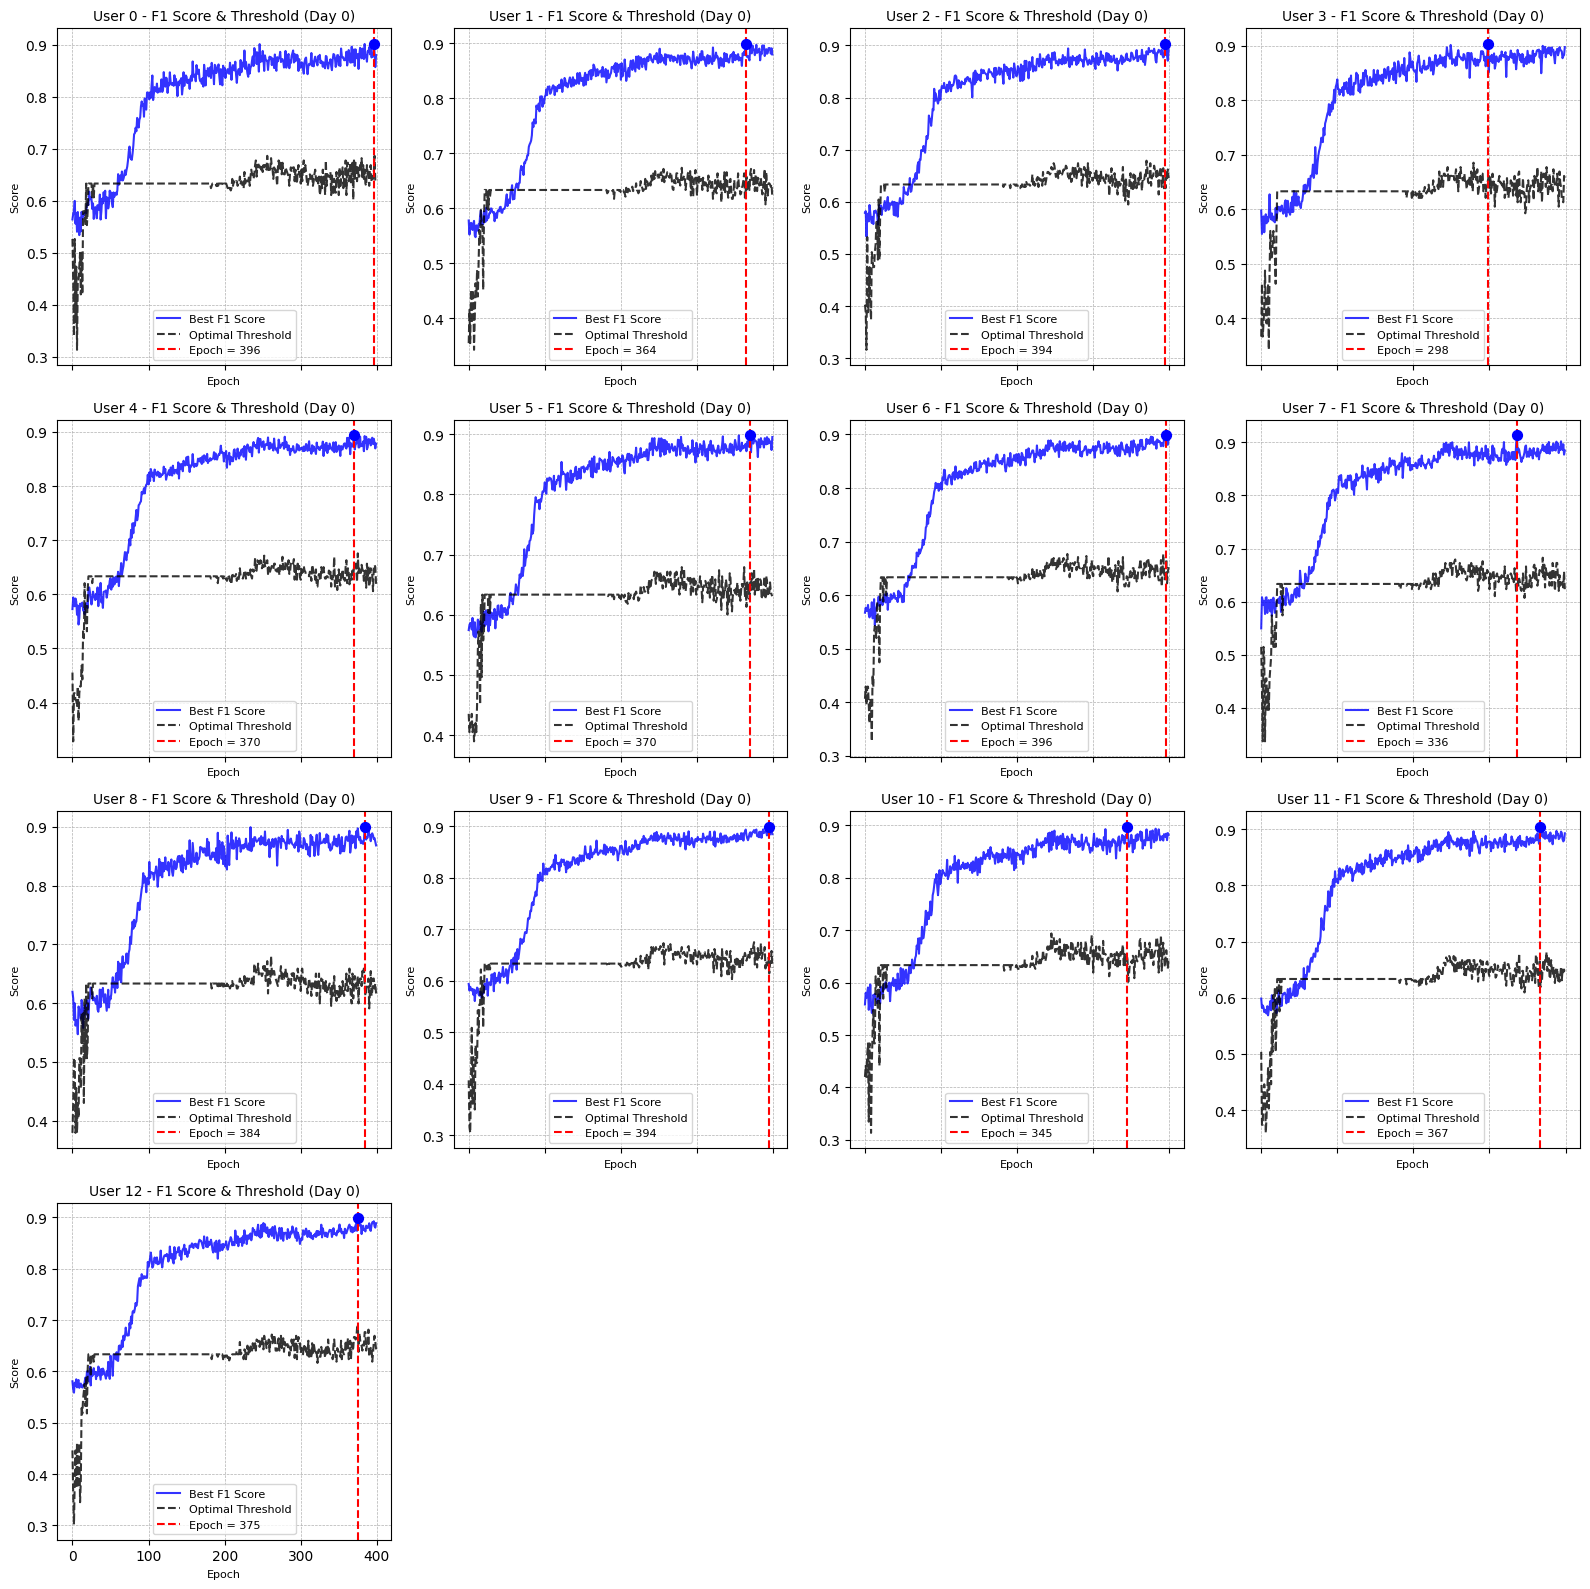

Max F1 Score and Optimal Threshold for Each User (Day 0):
User 0 -> Epoch: 396, Max F1 Score: 0.9026, Optimal Threshold: 0.6556
User 1 -> Epoch: 364, Max F1 Score: 0.8997, Optimal Threshold: 0.6313
User 2 -> Epoch: 394, Max F1 Score: 0.9035, Optimal Threshold: 0.6381
User 3 -> Epoch: 298, Max F1 Score: 0.9043, Optimal Threshold: 0.6535
User 4 -> Epoch: 370, Max F1 Score: 0.8939, Optimal Threshold: 0.6503
User 5 -> Epoch: 370, Max F1 Score: 0.8983, Optimal Threshold: 0.6562
User 6 -> Epoch: 396, Max F1 Score: 0.8987, Optimal Threshold: 0.6674
User 7 -> Epoch: 336, Max F1 Score: 0.9133, Optimal Threshold: 0.6531
User 8 -> Epoch: 384, Max F1 Score: 0.9000, Optimal Threshold: 0.6291
User 9 -> Epoch: 394, Max F1 Score: 0.8994, Optimal Threshold: 0.6447
User 10 -> Epoch: 345, Max F1 Score: 0.8973, Optimal Threshold: 0.6440
User 11 -> Epoch: 367, Max F1 Score: 0.9043, Optimal Threshold: 0.6189
User 12 -> Epoch: 375, Max F1 Score: 0.8984, Optimal Threshold: 0.6910


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/second_neural_network_a/version_2/metrics_per_user_day.csv"
metrics_user_df = pd.read_csv(file_path)

# Extract only relevant columns for train mode & day 0
train_data_day0 = metrics_user_df[
    (metrics_user_df["mode"] == "train") & (metrics_user_df["day"] == 0)
][["epoch", "user", "f1_score", "threshold"]]

# Get unique users
unique_users = sorted(train_data_day0["user"].unique())

# Create subplots (one for each user)
rows = len(unique_users) // 4 + (len(unique_users) % 4 > 0)  # Arrange in rows of 4
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows), sharex=True, sharey=False)
axes = axes.flatten()

# Dictionary to store max F1 score and corresponding threshold for each user
max_f1_info = {}

# Plot each user's F1 score & Threshold for Day 0
for i, user in enumerate(unique_users):
    user_data = train_data_day0[train_data_day0["user"] == user].groupby("epoch").mean(numeric_only=True)

    axes[i].plot(user_data.index, user_data["f1_score"], linestyle="-", color="blue", label="Best F1 Score", alpha=0.8)
    axes[i].plot(user_data.index, user_data["threshold"], linestyle="--", color="black", label="Optimal Threshold", alpha=0.8)
    
    # Find the epoch with the max F1 Score
    max_f1_epoch = user_data["f1_score"].idxmax()
    max_f1_score = user_data.loc[max_f1_epoch, "f1_score"]
    optimal_threshold = user_data.loc[max_f1_epoch, "threshold"]
    
    # Store the results
    max_f1_info[user] = {"Epoch": max_f1_epoch, "Max F1 Score": max_f1_score, "Optimal Threshold": optimal_threshold}

    axes[i].axvline(x=max_f1_epoch, color="red", linestyle="--", label=f"Epoch = {max_f1_epoch}")

    # Scatter plot max F1 Score
    axes[i].scatter(max_f1_epoch, user_data.loc[max_f1_epoch, "f1_score"], color="blue", s=50, zorder=5)

    # Titles & Legends
    axes[i].set_title(f"User {user} - F1 Score & Threshold (Day 0)", fontsize=10)
    axes[i].set_xlabel("Epoch", fontsize=8)
    axes[i].set_ylabel("Score", fontsize=8)
    axes[i].grid(True, linestyle="--", linewidth=0.5)
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

# Print Max F1 Score and Optimal Threshold for each user
print("Max F1 Score and Optimal Threshold for Each User (Day 0):")
for user, values in max_f1_info.items():
    print(f"User {user} -> Epoch: {values['Epoch']}, Max F1 Score: {values['Max F1 Score']:.4f}, Optimal Threshold: {values['Optimal Threshold']:.4f}")




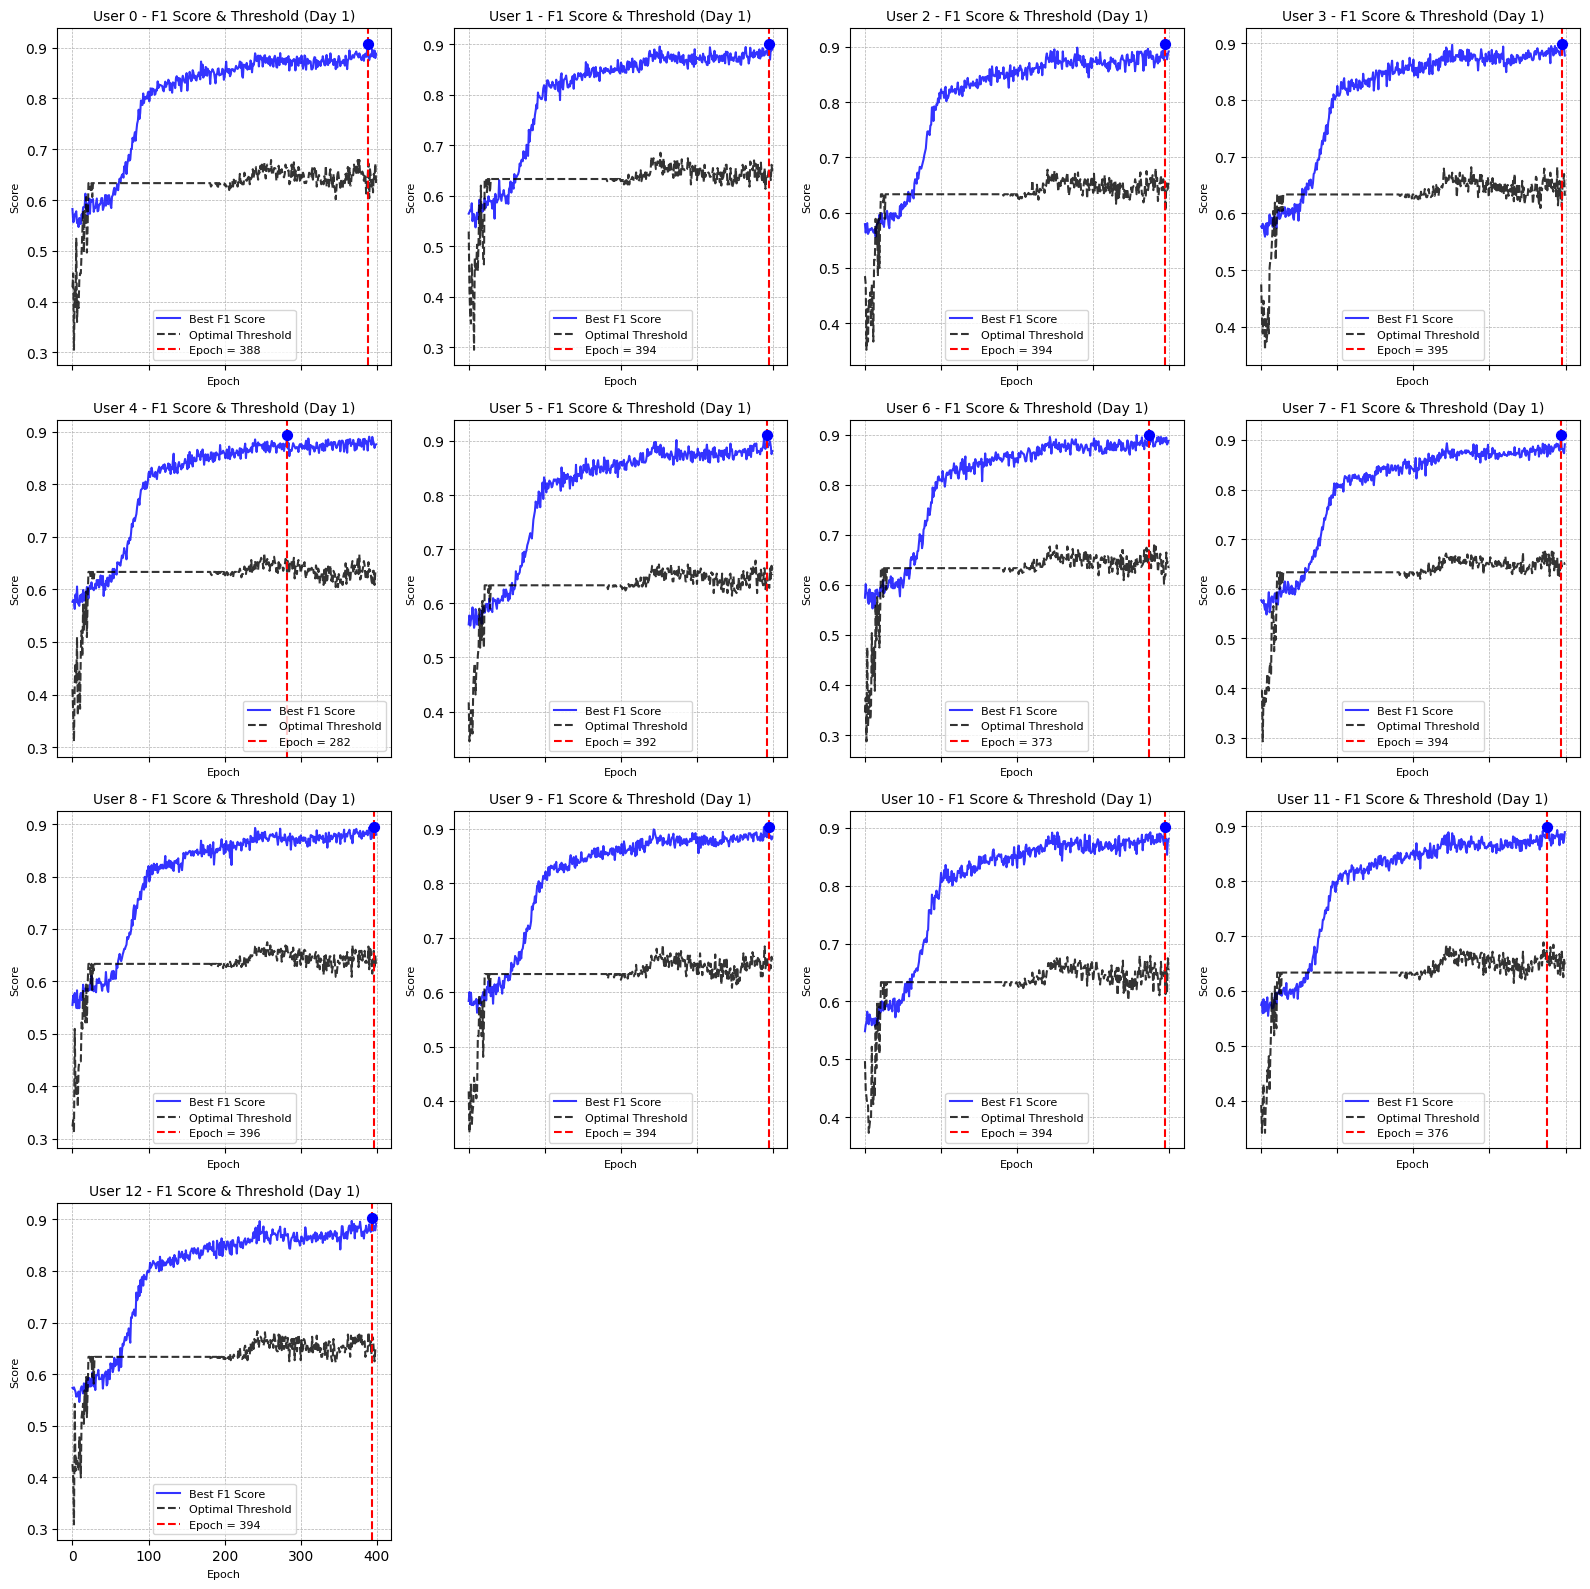

Max F1 Score and Optimal Threshold for Each User (Day 1):
User 0 -> Epoch: 388, Max F1 Score: 0.9080, Optimal Threshold: 0.6470
User 1 -> Epoch: 394, Max F1 Score: 0.9014, Optimal Threshold: 0.6485
User 2 -> Epoch: 394, Max F1 Score: 0.9059, Optimal Threshold: 0.6481
User 3 -> Epoch: 395, Max F1 Score: 0.8992, Optimal Threshold: 0.6117
User 4 -> Epoch: 282, Max F1 Score: 0.8936, Optimal Threshold: 0.6333
User 5 -> Epoch: 392, Max F1 Score: 0.9106, Optimal Threshold: 0.6502
User 6 -> Epoch: 373, Max F1 Score: 0.8989, Optimal Threshold: 0.6694
User 7 -> Epoch: 394, Max F1 Score: 0.9094, Optimal Threshold: 0.6579
User 8 -> Epoch: 396, Max F1 Score: 0.8950, Optimal Threshold: 0.6581
User 9 -> Epoch: 394, Max F1 Score: 0.9042, Optimal Threshold: 0.6418
User 10 -> Epoch: 394, Max F1 Score: 0.9019, Optimal Threshold: 0.6540
User 11 -> Epoch: 376, Max F1 Score: 0.8991, Optimal Threshold: 0.6524
User 12 -> Epoch: 394, Max F1 Score: 0.9024, Optimal Threshold: 0.6724


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/second_neural_network_a/version_2/metrics_per_user_day.csv"
metrics_user_df = pd.read_csv(file_path)

# Extract only relevant columns for train mode & day 1
train_data_day0 = metrics_user_df[
    (metrics_user_df["mode"] == "train") & (metrics_user_df["day"] == 1)
][["epoch", "user", "f1_score", "threshold"]]

# Get unique users
unique_users = sorted(train_data_day0["user"].unique())

# Create subplots (one for each user)
rows = len(unique_users) // 4 + (len(unique_users) % 4 > 0)  # Arrange in rows of 4
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows), sharex=True, sharey=False)
axes = axes.flatten()

# Dictionary to store max F1 score and corresponding threshold for each user
max_f1_info = {}

# Plot each user's F1 score & Threshold for Day 1
for i, user in enumerate(unique_users):
    user_data = train_data_day0[train_data_day0["user"] == user].groupby("epoch").mean(numeric_only=True)

    axes[i].plot(user_data.index, user_data["f1_score"], linestyle="-", color="blue", label="Best F1 Score", alpha=0.8)
    axes[i].plot(user_data.index, user_data["threshold"], linestyle="--", color="black", label="Optimal Threshold", alpha=0.8)
    
    # Find the epoch with the max F1 Score
    max_f1_epoch = user_data["f1_score"].idxmax()
    max_f1_score = user_data.loc[max_f1_epoch, "f1_score"]
    optimal_threshold = user_data.loc[max_f1_epoch, "threshold"]
    
    # Store the results
    max_f1_info[user] = {"Epoch": max_f1_epoch, "Max F1 Score": max_f1_score, "Optimal Threshold": optimal_threshold}

    axes[i].axvline(x=max_f1_epoch, color="red", linestyle="--", label=f"Epoch = {max_f1_epoch}")

    # Scatter plot max F1 Score
    axes[i].scatter(max_f1_epoch, user_data.loc[max_f1_epoch, "f1_score"], color="blue", s=50, zorder=5)

    # Titles & Legends
    axes[i].set_title(f"User {user} - F1 Score & Threshold (Day 1)", fontsize=10)
    axes[i].set_xlabel("Epoch", fontsize=8)
    axes[i].set_ylabel("Score", fontsize=8)
    axes[i].grid(True, linestyle="--", linewidth=0.5)
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

# Print Max F1 Score and Optimal Threshold for each user
print("Max F1 Score and Optimal Threshold for Each User (Day 1):")
for user, values in max_f1_info.items():
    print(f"User {user} -> Epoch: {values['Epoch']}, Max F1 Score: {values['Max F1 Score']:.4f}, Optimal Threshold: {values['Optimal Threshold']:.4f}")




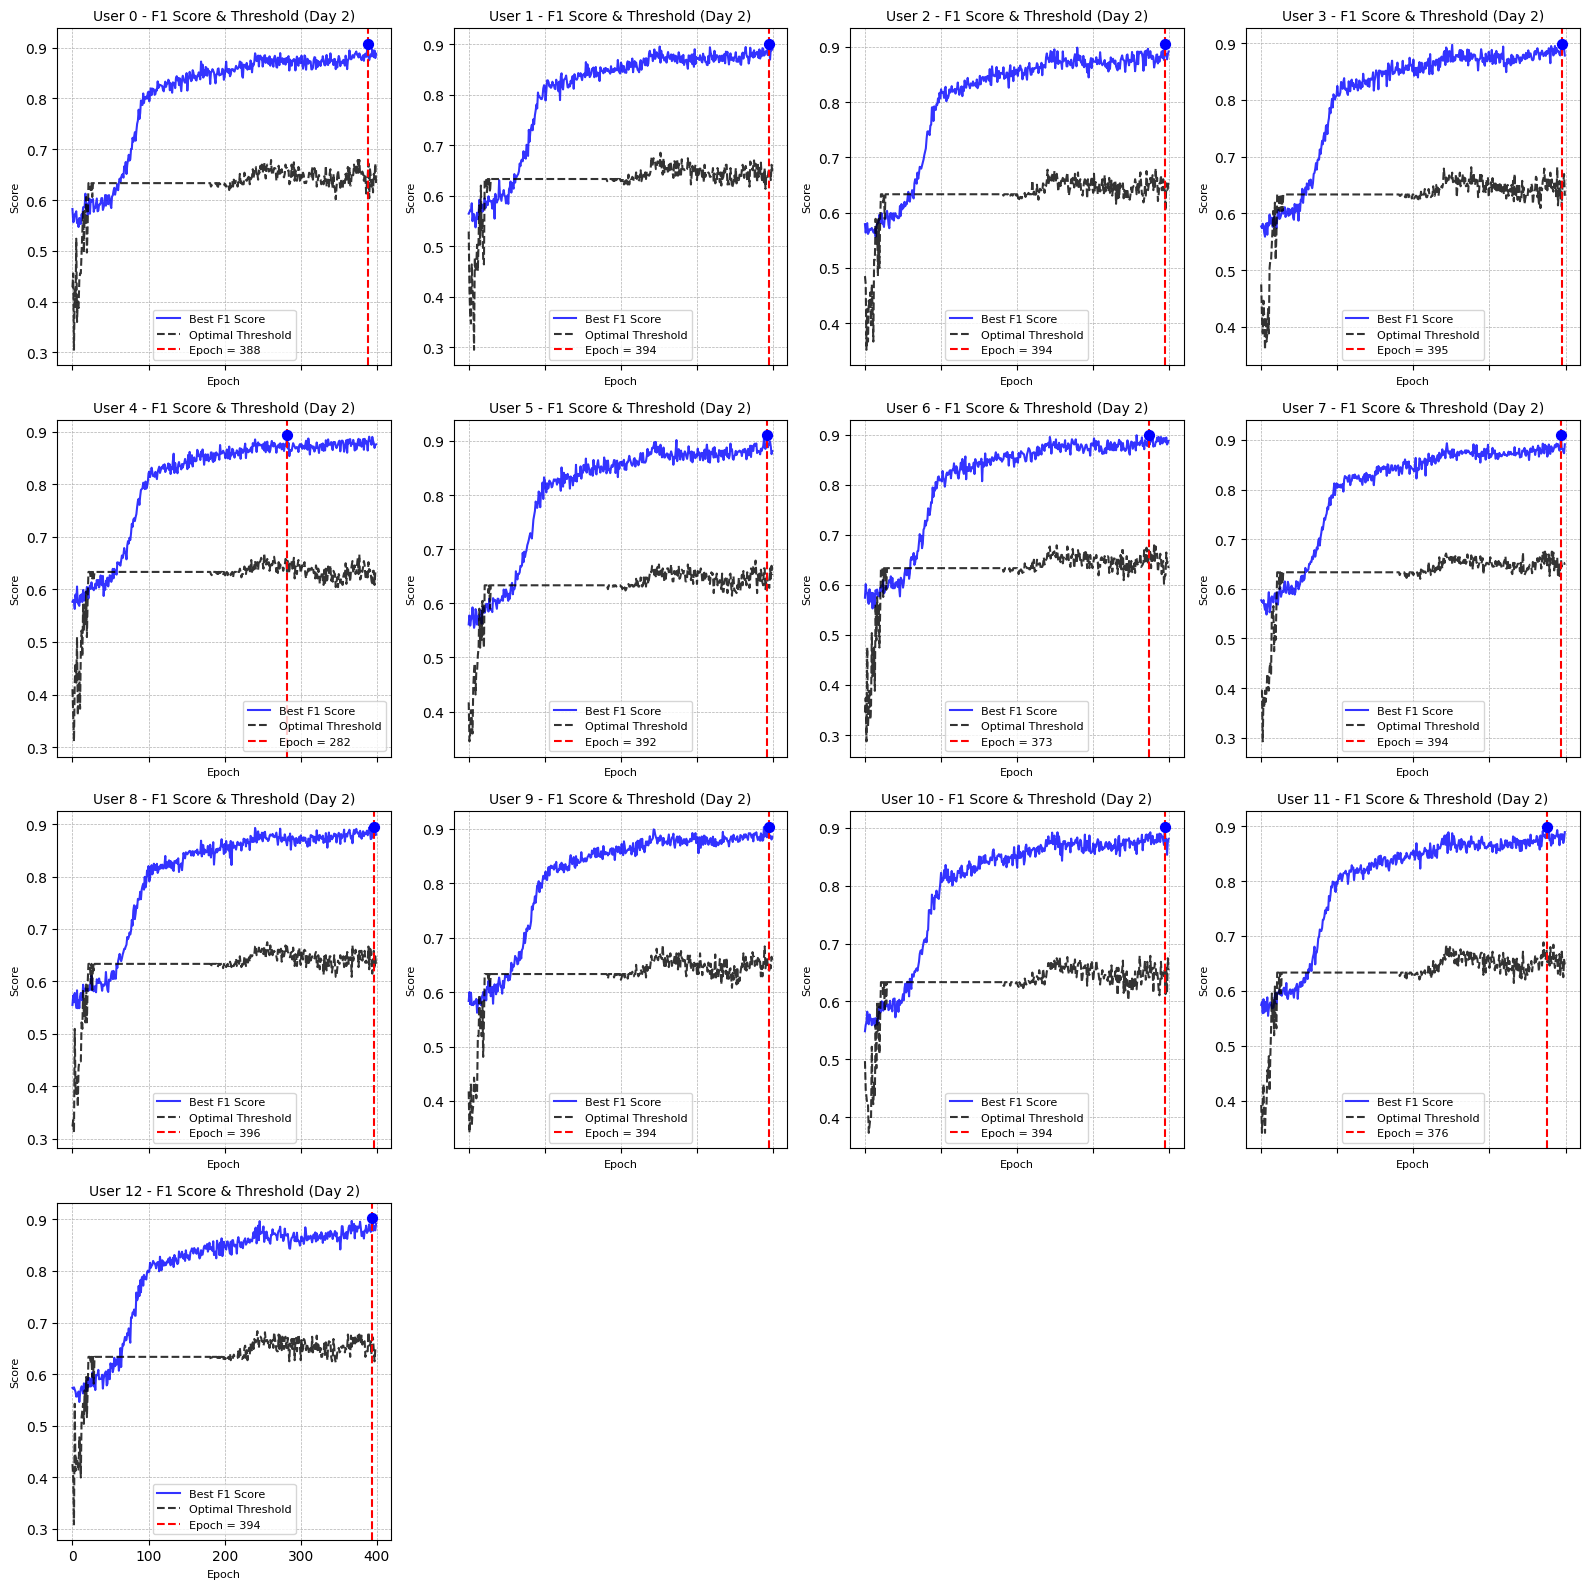

Max F1 Score and Optimal Threshold for Each User (Day 2):
User 0 -> Epoch: 388, Max F1 Score: 0.9080, Optimal Threshold: 0.6470
User 1 -> Epoch: 394, Max F1 Score: 0.9014, Optimal Threshold: 0.6485
User 2 -> Epoch: 394, Max F1 Score: 0.9059, Optimal Threshold: 0.6481
User 3 -> Epoch: 395, Max F1 Score: 0.8992, Optimal Threshold: 0.6117
User 4 -> Epoch: 282, Max F1 Score: 0.8936, Optimal Threshold: 0.6333
User 5 -> Epoch: 392, Max F1 Score: 0.9106, Optimal Threshold: 0.6502
User 6 -> Epoch: 373, Max F1 Score: 0.8989, Optimal Threshold: 0.6694
User 7 -> Epoch: 394, Max F1 Score: 0.9094, Optimal Threshold: 0.6579
User 8 -> Epoch: 396, Max F1 Score: 0.8950, Optimal Threshold: 0.6581
User 9 -> Epoch: 394, Max F1 Score: 0.9042, Optimal Threshold: 0.6418
User 10 -> Epoch: 394, Max F1 Score: 0.9019, Optimal Threshold: 0.6540
User 11 -> Epoch: 376, Max F1 Score: 0.8991, Optimal Threshold: 0.6524
User 12 -> Epoch: 394, Max F1 Score: 0.9024, Optimal Threshold: 0.6724


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/second_neural_network_a/version_2/metrics_per_user_day.csv"
metrics_user_df = pd.read_csv(file_path)

# Extract only relevant columns for train mode & day 2
train_data_day0 = metrics_user_df[
    (metrics_user_df["mode"] == "train") & (metrics_user_df["day"] == 1)
][["epoch", "user", "f1_score", "threshold"]]

# Get unique users
unique_users = sorted(train_data_day0["user"].unique())

# Create subplots (one for each user)
rows = len(unique_users) // 4 + (len(unique_users) % 4 > 0)  # Arrange in rows of 4
fig, axes = plt.subplots(rows, 4, figsize=(16, 4 * rows), sharex=True, sharey=False)
axes = axes.flatten()

# Dictionary to store max F1 score and corresponding threshold for each user
max_f1_info = {}

# Plot each user's F1 score & Threshold for Day 2
for i, user in enumerate(unique_users):
    user_data = train_data_day0[train_data_day0["user"] == user].groupby("epoch").mean(numeric_only=True)

    axes[i].plot(user_data.index, user_data["f1_score"], linestyle="-", color="blue", label="Best F1 Score", alpha=0.8)
    axes[i].plot(user_data.index, user_data["threshold"], linestyle="--", color="black", label="Optimal Threshold", alpha=0.8)
    
    # Find the epoch with the max F1 Score
    max_f1_epoch = user_data["f1_score"].idxmax()
    max_f1_score = user_data.loc[max_f1_epoch, "f1_score"]
    optimal_threshold = user_data.loc[max_f1_epoch, "threshold"]
    
    # Store the results
    max_f1_info[user] = {"Epoch": max_f1_epoch, "Max F1 Score": max_f1_score, "Optimal Threshold": optimal_threshold}

    axes[i].axvline(x=max_f1_epoch, color="red", linestyle="--", label=f"Epoch = {max_f1_epoch}")

    # Scatter plot max F1 Score
    axes[i].scatter(max_f1_epoch, user_data.loc[max_f1_epoch, "f1_score"], color="blue", s=50, zorder=5)

    # Titles & Legends
    axes[i].set_title(f"User {user} - F1 Score & Threshold (Day 2)", fontsize=10)
    axes[i].set_xlabel("Epoch", fontsize=8)
    axes[i].set_ylabel("Score", fontsize=8)
    axes[i].grid(True, linestyle="--", linewidth=0.5)
    axes[i].legend(fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()
plt.show()

# Print Max F1 Score and Optimal Threshold for each user
print("Max F1 Score and Optimal Threshold for Each User (Day 2):")
for user, values in max_f1_info.items():
    print(f"User {user} -> Epoch: {values['Epoch']}, Max F1 Score: {values['Max F1 Score']:.4f}, Optimal Threshold: {values['Optimal Threshold']:.4f}")




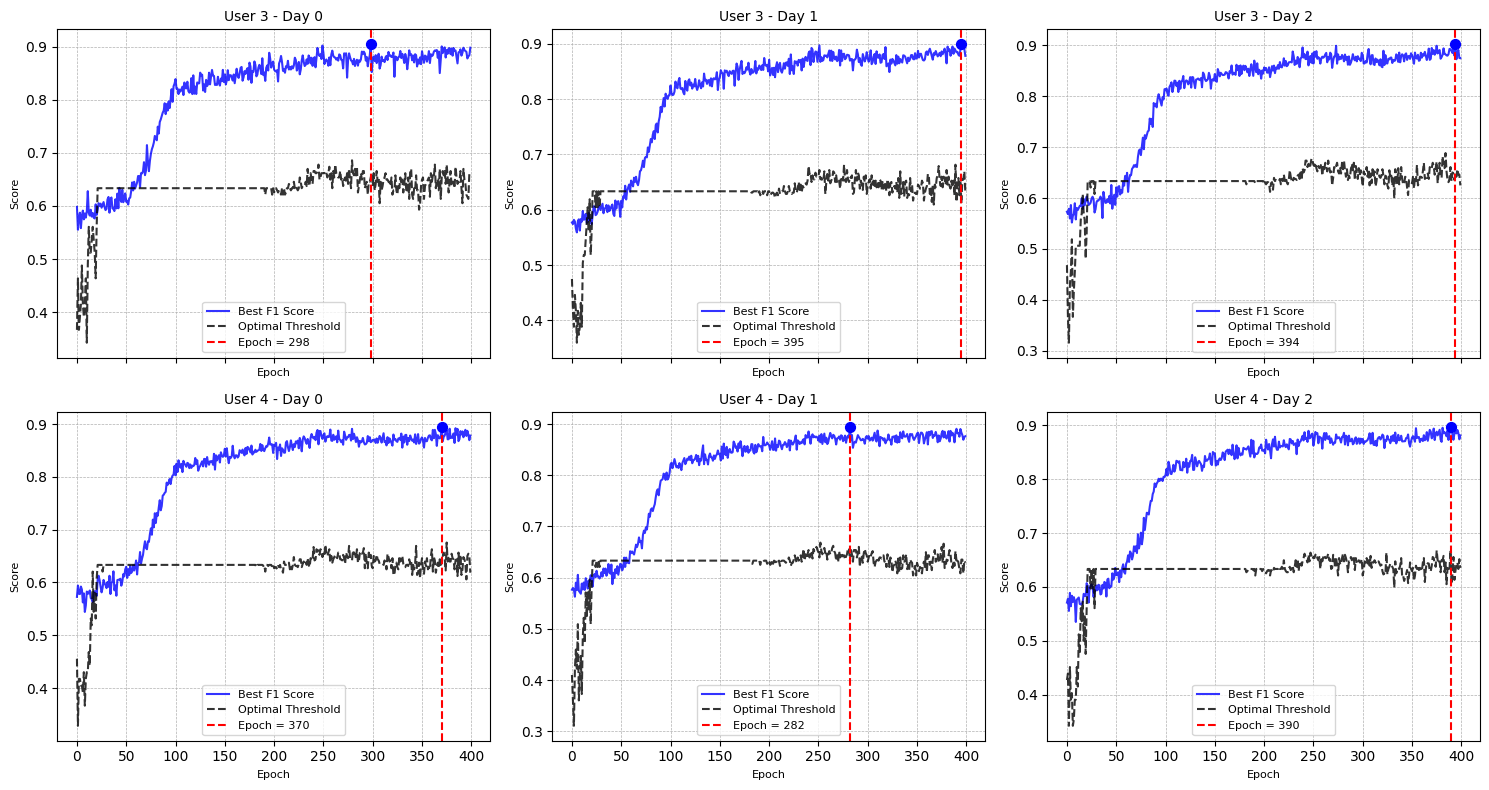

Max F1 Score and Optimal Threshold for Each User & Day:
User 3, Day 0 -> Epoch: 298, Max F1 Score: 0.9043, Optimal Threshold: 0.6535
User 3, Day 1 -> Epoch: 395, Max F1 Score: 0.8992, Optimal Threshold: 0.6117
User 3, Day 2 -> Epoch: 394, Max F1 Score: 0.9020, Optimal Threshold: 0.6481
User 4, Day 0 -> Epoch: 370, Max F1 Score: 0.8939, Optimal Threshold: 0.6503
User 4, Day 1 -> Epoch: 282, Max F1 Score: 0.8936, Optimal Threshold: 0.6333
User 4, Day 2 -> Epoch: 390, Max F1 Score: 0.8961, Optimal Threshold: 0.6051


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your metrics data
file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/second_neural_network_a/version_2/metrics_per_user_day.csv"
metrics_user_df = pd.read_csv(file_path)

# Filter data for users 3 and 4 across all three days
filtered_data = metrics_user_df[
    (metrics_user_df["user"].isin([3, 4])) & (metrics_user_df["mode"] == "train")
]

# Define unique users and days
users = [3, 4]
days = [0, 1, 2]

# Create subplots (2 users × 3 days)
fig, axes = plt.subplots(len(users), len(days), figsize=(15, 8), sharex=True, sharey=False)
axes = axes.flatten()

# Dictionary to store max F1 score and corresponding threshold for each user & day
max_f1_info = {}

# Plot for each user and day
plot_index = 0
for user in users:
    for day in days:
        user_day_data = filtered_data[
            (filtered_data["user"] == user) & (filtered_data["day"] == day)
        ].groupby("epoch").mean(numeric_only=True)

        if not user_day_data.empty:
            # Plot F1 Score and Threshold
            axes[plot_index].plot(user_day_data.index, user_day_data["f1_score"], linestyle="-", color="blue", label="Best F1 Score", alpha=0.8)
            axes[plot_index].plot(user_day_data.index, user_day_data["threshold"], linestyle="--", color="black", label="Optimal Threshold", alpha=0.8)

            # Find the epoch with the max F1 Score
            max_f1_epoch = user_day_data["f1_score"].idxmax()
            max_f1_score = user_day_data.loc[max_f1_epoch, "f1_score"]
            optimal_threshold = user_day_data.loc[max_f1_epoch, "threshold"]

            # Store the results
            max_f1_info[(user, day)] = {"Epoch": max_f1_epoch, "Max F1 Score": max_f1_score, "Optimal Threshold": optimal_threshold}

            # Highlight max F1 Score
            axes[plot_index].axvline(x=max_f1_epoch, color="red", linestyle="--", label=f"Epoch = {max_f1_epoch}")
            axes[plot_index].scatter(max_f1_epoch, max_f1_score, color="blue", s=50, zorder=5)

            # Titles & Legends
            axes[plot_index].set_title(f"User {user} - Day {day}", fontsize=10)
            axes[plot_index].set_xlabel("Epoch", fontsize=8)
            axes[plot_index].set_ylabel("Score", fontsize=8)
            axes[plot_index].grid(True, linestyle="--", linewidth=0.5)
            axes[plot_index].legend(fontsize=8)

        plot_index += 1

# Adjust layout
plt.tight_layout()
plt.show()

# Print Max F1 Score and Optimal Threshold for each user & day
print("Max F1 Score and Optimal Threshold for Each User & Day:")
for (user, day), values in max_f1_info.items():
    print(f"User {user}, Day {day} -> Epoch: {values['Epoch']}, Max F1 Score: {values['Max F1 Score']:.4f}, Optimal Threshold: {values['Optimal Threshold']:.4f}")


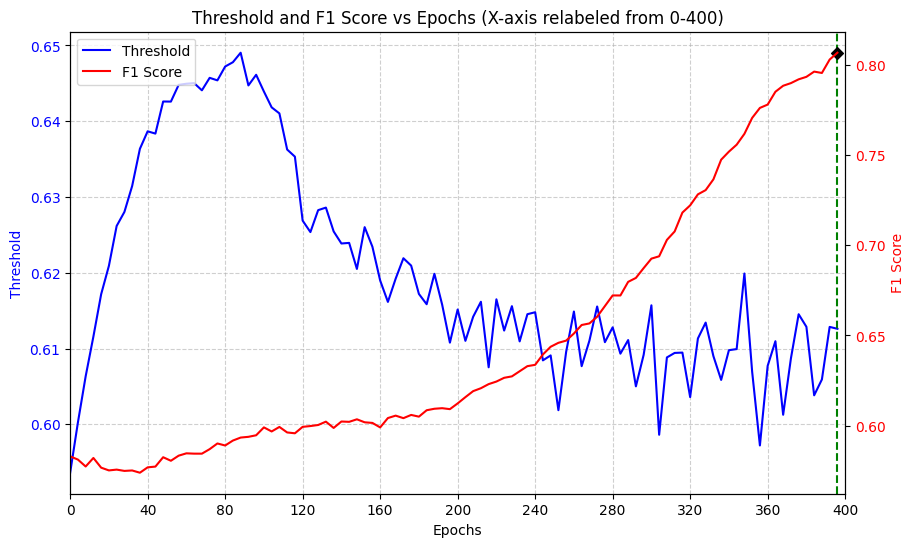

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Define file paths for the two CSV files
f1_score_file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/second_neural_network_a/version_2/metrics_overall.csv"  # File containing F1 Score
threshold_file_path = "D:/TU Darmstadt/Thesis/presence_prediction/tud_presence_prediction/training_results/second_neural_network/version_6/metrics_all.csv"     # File containing Threshold

# Load both CSV files
f1_data = pd.read_csv(f1_score_file_path)
threshold_data = pd.read_csv(threshold_file_path)

# Group by epoch and calculate mean values for F1 Score from version 2 and Threshold from version 6
f1_epoch_grouped = f1_data.groupby("epoch")["f1_score"].mean()
threshold_epoch_grouped = threshold_data.groupby("epoch")["threshold"].mean()

# Merge the data on epoch to ensure alignment
merged_data = pd.merge(f1_epoch_grouped, threshold_epoch_grouped, on="epoch")

# Find the optimal epoch where F1 score is maximized
optimal_epoch = merged_data["f1_score"].idxmax()
optimal_f1_score = merged_data.loc[optimal_epoch, "f1_score"]
optimal_threshold = merged_data.loc[optimal_epoch, "threshold"]

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot threshold on the primary y-axis
line1, = ax1.plot(merged_data.index, merged_data["threshold"], label="Threshold", color="blue")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Threshold", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

# Set x-axis to display 0-100 epochs but label it as 0-400 epochs
ax1.set_xlim(0, 100)  # Data is actually plotted for 0-100 epochs
ax1.set_xticks(range(0, 101, 10))  # Use real range of 0-100
ax1.set_xticklabels(range(0, 401, 40))  # Label it as 0-400 instead of 0-100

# Create a second y-axis for F1 score
ax2 = ax1.twinx()
line2, = ax2.plot(merged_data.index, merged_data["f1_score"], label="F1 Score", color="red")
ax2.set_ylabel("F1 Score", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Mark the optimal threshold at max F1 score
ax1.axvline(optimal_epoch, color="green", linestyle="--", label=f"Optimal Threshold (Epoch {optimal_epoch})")
ax2.scatter(optimal_epoch, optimal_f1_score, color="black", marker="D", label=f"Max F1 Score: {optimal_f1_score:.4f}")

# Title and grid
plt.title("Threshold and F1 Score vs Epochs (X-axis relabeled from 0-400)")
ax1.grid(True, linestyle="--", alpha=0.6)

# Add a legend box combining both lines
plt.legend([line1, line2], ["Threshold", "F1 Score"], loc="upper left", fontsize=10, frameon=True)

# Show plot
plt.show()


In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

# Assuming y_true are the true labels and y_scores are the predicted scores
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Plotting the Precision-Recall curve
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()
plt.title('Precision-Recall Curve')
plt.show()


NameError: name 'y_true' is not defined